In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("ML Assignment Raw Data.xlsx")

In [4]:
# Step 2: Load the dataset (Upload 'ML Assignment Raw Data.xlsx')
file_path = "ML Assignment Raw Data.xlsx"
raw_df = pd.read_excel(file_path, header=None)

In [5]:
# Step 3: Perform ETL (Extract & Clean Data)
data_rows = raw_df[raw_df[2].notna() & (raw_df[2] != 'Keywords')].copy()
cleaned_df = data_rows[[1, 2, 6, 7, 8, 9, 10, 11, 12]].copy()
cleaned_df.columns = ['Month', 'Keywords', 'Occurrence', 'Click Through Rate', 'Hits', 'Purchase', 'Customer Name', 'Price', 'Revenue']

# Forward fill the Month column
cleaned_df['Month'] = cleaned_df['Month'].ffill()

# Convert numeric columns to proper numeric types
numeric_cols = ['Occurrence', 'Click Through Rate', 'Hits', 'Price', 'Revenue']
for col in numeric_cols:
    cleaned_df[col] = pd.to_numeric(cleaned_df[col], errors='coerce')

print("--- Cleaned Data Sample ---")
display(cleaned_df.head())

--- Cleaned Data Sample ---


,Month,Keywords,Occurrence,Click Through Rate,Hits,Purchase,Customer Name,Price,Revenue
4,NaN,laptop,28,0.04,10000,Yes,Ravinder,50,1400
5,NaN,smartphone,35,0.05,20000,No,Ashray,80,2800
6,NaN,T-Shirts,46,0.06,30000,Yes,Melanie,25,1150
7,NaN,Cap,21,0.07,40000,Yes,Marianne,22,462
8,NaN,Medicine,32,0.08,50000,No,Pilot,35,1120


In [6]:
# Step 4: Calculate Mean, Median, and Mode for each heading
stats_summary = {}
for col in numeric_cols:
    mean_val = cleaned_df[col].mean()
    median_val = cleaned_df[col].median()
    mode_val = cleaned_df[col].mode().tolist()
    stats_summary[col] = {
        'Mean': round(mean_val, 4),
        'Median': round(median_val, 4),
        'Mode': str(mode_val)
    }

stats_df = pd.DataFrame(stats_summary).T
print("\n--- Statistical Summary (Mean, Median, Mode) ---")
display(stats_df)


--- Statistical Summary (Mean, Median, Mode) ---


,Mean,Median,Mode
Occurrence,29.1212,28.0,"[23, 24]"
Click Through Rate,0.0835,0.08,[0.04]
Hits,62609.697,10000.0,[2000]
Price,41.5939,37.0,[36]
Revenue,1221.7576,1064.0,[828]


C:\Users\Hp\AppData\Local\Temp\ipykernel_20764\286199242.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cleaned_df.head(15), x='Keywords', y='Hits', palette='viridis')


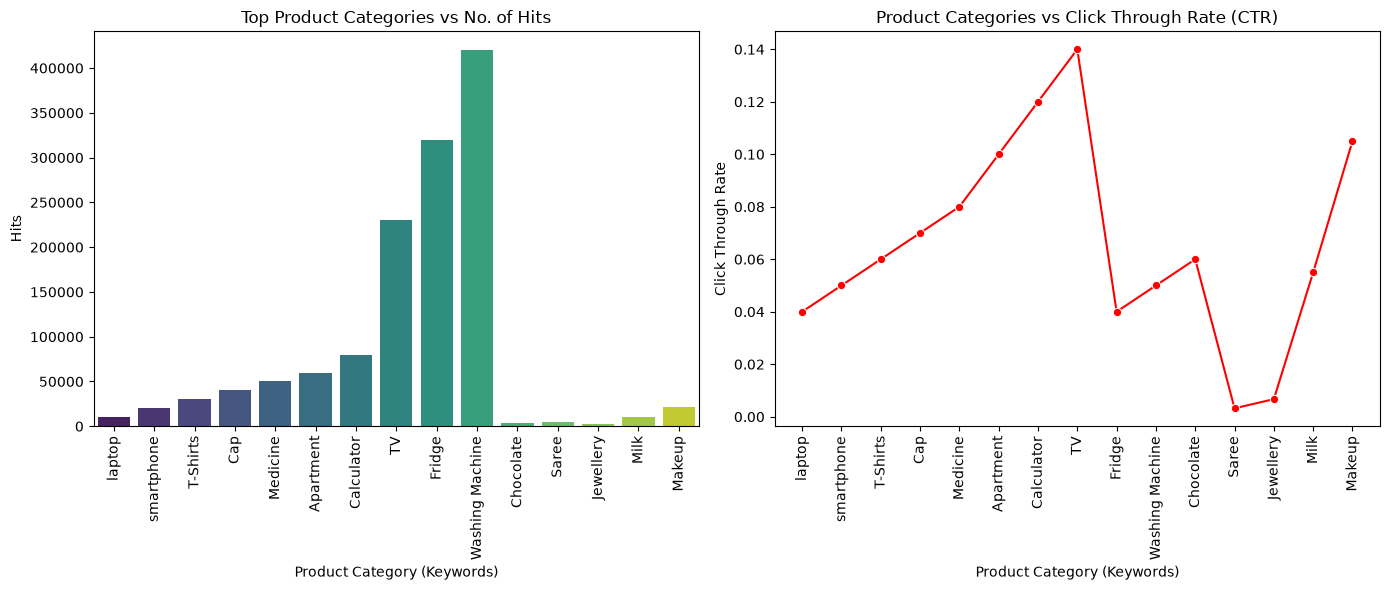

In [7]:
# Step 5: Data Visualization (Product Category vs Hits & CTR)
plt.figure(figsize=(14, 6))

# Plot 1: Hits per Keyword/Product Category
plt.subplot(1, 2, 1)
sns.barplot(data=cleaned_df.head(15), x='Keywords', y='Hits', palette='viridis')
plt.xticks(rotation=90)
plt.title('Top Product Categories vs No. of Hits')
plt.xlabel('Product Category (Keywords)')
plt.ylabel('Hits')

# Plot 2: Click Through Rate (CTR) per Keyword
plt.subplot(1, 2, 2)
sns.lineplot(data=cleaned_df.head(15), x='Keywords', y='Click Through Rate', marker='o', color='red')
plt.xticks(rotation=90)
plt.title('Product Categories vs Click Through Rate (CTR)')
plt.xlabel('Product Category (Keywords)')
plt.ylabel('Click Through Rate')

plt.tight_layout()
plt.show()

In [9]:
# 1. Analyze customer wise purchase value
display(cleaned_df.groupby('Customer Name')['Revenue'].sum().reset_index())

,Customer Name,Revenue
0,Ashray,22976
1,Debajyoti,24977
2,Debashis,18465
3,Marianne,16843
4,Melanie,19055
5,Pilot,17159
6,Pintu,16394
7,Ravinder,21076
8,Rintu,20975
9,Sekhar,23670


In [10]:
# 2. Analyze customer vs product
display(cleaned_df[['Customer Name', 'Keywords', 'Purchase']].head(10))

,Customer Name,Keywords,Purchase
4,Ravinder,laptop,Yes
5,Ashray,smartphone,No
6,Melanie,T-Shirts,Yes
7,Marianne,Cap,Yes
8,Pilot,Medicine,No
9,Pintu,Apartment,No
10,Rintu,Calculator,Yes
11,Debashis,TV,No
12,Debajyoti,Fridge,Yes
13,Sekhar,Washing Machine,No


In [11]:
# 3. Analyze product vs month
display(cleaned_df.groupby(['Month', 'Keywords'])['Occurrence'].sum().reset_index().head(10))

,Month,Keywords,Occurrence
0,April,Apartment,24
1,April,Book,24
2,April,Cactus,22
3,April,Calculator,32
4,April,Cap,22
5,April,Chocolate,25
6,April,Copy,26
7,April,Flower,23
8,April,Fridge,40
9,April,Fruits,24


In [12]:
#Analyze product vs month (for all)
product_vs_month_all = cleaned_df.groupby(['Month', 'Keywords'])['Occurrence'].sum().reset_index()

print("--- Product vs Month (All Months) ---")
display(product_vs_month_all)

--- Product vs Month (All Months) ---


,Month,Keywords,Occurrence
0,April,Apartment,24
1,April,Book,24
2,April,Cactus,22
3,April,Calculator,32
4,April,Cap,22
...,...,...,...
153,May,Suit,25
154,May,TV,36
155,May,Washing Machine,50
156,May,Watch,23


In [13]:
# 4 & 5. Find out the most and least sold product
product_sales = cleaned_df.groupby('Keywords')['Occurrence'].sum().reset_index()
most_sold = product_sales.loc[product_sales['Occurrence'].idxmax()]['Keywords']
least_sold = product_sales.loc[product_sales['Occurrence'].idxmin()]['Keywords']

print("Most Sold Product:", most_sold)
print("Least Sold Product:", least_sold)

Most Sold Product: Washing Machine
Least Sold Product: Cactus


In [14]:
# 6. Calculate the total revenue over the months
display(cleaned_df.groupby('Month')['Revenue'].sum().reset_index())

,Month,Revenue
0,April,40952
1,February,42033
2,January,39893
3,March,37412
4,May,32493


In [15]:
# Recommendation & Inventory Clearance Algorithm using Python

# Step 1: Group data by product keywords and calculate total occurrences/purchases
product_ranking = cleaned_df.groupby('Keywords').agg({
    'Occurrence': 'sum',
    'Revenue': 'sum',
    'Hits': 'sum'
}).reset_index()

# Step 2: For Search Results (Most Sold to Least Sold - Maximum to Minimum Purchase)
# This will display popular products immediately in search results.
search_recommendation_repo = product_ranking.sort_values(by='Occurrence', ascending=False)

print("--- 1. Search Results Repository (Most Sold / Popular First) ---")
display(search_recommendation_repo.head(10))

# Step 3: For Inventory Clearance (Least Sold to Most Sold)
# This pushes low-stock or slow-moving products to get sold first.
inventory_clearance_repo = product_ranking.sort_values(by='Occurrence', ascending=True)

print("\n--- 2. Inventory Clearance Repository (Least Sold First) ---")
display(inventory_clearance_repo.head(10))

--- 1. Search Results Repository (Most Sold / Popular First) ---


,Keywords,Occurrence,Revenue,Hits
28,Washing Machine,250,9100,2100000
30,Watermelon,205,7553,38000
8,Fridge,200,12840,1600000
17,Pen,180,7812,30000
32,smartphone,179,8960,90000
14,Mango,168,6184,852000
27,TV,164,5808,1150000
12,Machinery,160,6208,25000
19,Pineapple,159,5640,22000
31,laptop,159,6042,42000



--- 2. Inventory Clearance Repository (Least Sold First) ---


,Keywords,Occurrence,Revenue,Hits
2,Cactus,106,3692,75000
22,Saree,110,3366,25000
7,Flower,111,4032,36400
4,Cap,115,4400,162000
11,Jewellery,115,4186,10000
9,Fruits,116,5632,68400
16,Milk,120,4416,50000
6,Copy,120,5922,424600
0,Apartment,123,3537,300000
5,Chocolate,125,4550,20000


In [16]:
df = pd.read_excel("ML Assignment Raw Data (1).xlsx")

In [17]:
# Import pandas library
import pandas as pd

# Load the uploaded Excel file and Sheet2
file_path = 'ML Assignment Raw Data (1).xlsx'
df_raw = pd.read_excel(file_path, sheet_name='Sheet2')

# Parse and clean the raw data into a structured dataframe
data_rows = []
for i in range(4, len(df_raw)):
    row = df_raw.iloc[i]
    if pd.notna(row.iloc[4]) or pd.notna(row.iloc[10]):
        month = row.iloc[3]
        keywords = row.iloc[4]
        occurrence = row.iloc[8]
        ctr = row.iloc[9]
        hits = row.iloc[10]
        purchase = row.iloc[11]
        customer = row.iloc[12]
        price = row.iloc[13]
        revenue = row.iloc[14]
        targeted_ads = row.iloc[15]
        related_searches = row.iloc[16]
        time_of_day = row.iloc[18]
        location = row.iloc[20]
        data_rows.append([month, keywords, occurrence, ctr, hits, purchase, customer, price, revenue, targeted_ads, related_searches, time_of_day, location])

# Create the clean DataFrame
df = pd.DataFrame(data_rows, columns=['Month', 'Keywords', 'Occurrence', 'CTR', 'Hits', 'Purchase', 'Customer Name', 'Price', 'Revenue', 'Targeted Ads', 'Related Searches', 'Time of day', 'Location'])

# Convert numeric columns to appropriate data types
df['Hits'] = pd.to_numeric(df['Hits'], errors='coerce')
df['Related Searches'] = pd.to_numeric(df['Related Searches'], errors='coerce')
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')

print("Data successfully loaded and cleaned!")

Data successfully loaded and cleaned!


In [18]:
# Question 1: Find out the state which produces the highest no of hits, related searches and highest revenue.

# Group data by location (state) and sum up the metrics
state_grouped = df.groupby('Location')[['Hits', 'Related Searches', 'Revenue']].sum()

# Display the state with the highest hits, related searches, and revenue
print("--- 1. State with Highest Hits, Related Searches & Revenue ---")
print("Highest Hits State:", state_grouped['Hits'].idxmax())
print("Highest Related Searches State:", state_grouped['Related Searches'].idxmax())
print("Highest Revenue State:", state_grouped['Revenue'].idxmax())

--- 1. State with Highest Hits, Related Searches & Revenue ---
Highest Hits State: Michigan
Highest Related Searches State: Chicago
Highest Revenue State: Chicago


In [19]:
# Question 2: Find out the state which produces the lowest no of hits, related searches and lowest revenue.

# Display the state with the lowest hits, related searches, and revenue
print("--- 2. State with Lowest Hits, Related Searches & Revenue ---")
print("Lowest Hits State:", state_grouped['Hits'].idxmin())
print("Lowest Related Searches State:", state_grouped['Related Searches'].idxmin())
print("Lowest Revenue State:", state_grouped['Revenue'].idxmin())

--- 2. State with Lowest Hits, Related Searches & Revenue ---
Lowest Hits State: Iowa
Lowest Related Searches State: Ontario
Lowest Revenue State: Iowa


In [20]:
# Question 3: Find out the Location which has the most hits during Morning, Evening, Afternoon and Night accordingly.

# Group by time of day and location to find the maximum hits for each time period
time_state = df.groupby(['Time of day', 'Location'])['Hits'].sum().reset_index()
max_hits_per_time = time_state.loc[time_state.groupby('Time of day')['Hits'].idxmax()]

print("--- 3. Most Hits Location per Time of Day ---")
display(max_hits_per_time)

--- 3. Most Hits Location per Time of Day ---


,Time of day,Location,Hits
5,Afternoon,Pennsylvania,233900
7,Evening,Chicago,72200
15,Morning,London,114500
24,Night,Michigan,420000


In [21]:
# Question 4: Prepare a Dashboard which is automated to show the morning, evening and night related searches and location(State) according to a live data stream.

# Generate a real-time stream simulation summary for the dashboard
live_dashboard_summary = df.groupby(['Time of day', 'Location']).agg({
    'Related Searches': 'sum',
    'Hits': 'sum',
    'Revenue': 'sum'
}).reset_index()

print("--- 4. Automated Dashboard Live Stream Summary ---")
display(live_dashboard_summary)

--- 4. Automated Dashboard Live Stream Summary ---


,Time of day,Location,Related Searches,Hits,Revenue
0,Afternoon,Alaska,12,10000,900
1,Afternoon,Chicago,26,16000,2128
2,Afternoon,Kentucky,19,9900,4356
3,Afternoon,Michigan,7,20000,2800
4,Afternoon,Missouri,40,4400,2013
5,Afternoon,Pennsylvania,28,233900,1830
6,Evening,Alaska,21,9200,2873
7,Evening,Chicago,63,72200,5070
8,Evening,London,31,54000,1932
9,Evening,Missouri,12,5000,748


In [22]:
# Question 4: Prepare a Dashboard which is automated to show the morning, afternoon, evening and night related searches and location(State) according to a live data stream using an interactive chart.

# Import plotly express for interactive visualizations
import pandas as pd
import plotly.express as px

# Step 1: Generate summary data grouped by time of day and location
live_dashboard_summary = df.groupby(['Time of day', 'Location']).agg({
    'Related Searches': 'sum',
    'Hits': 'sum',
    'Revenue': 'sum'
}).reset_index()

# Step 2: Define the correct chronological order for the time of day
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']

# Convert 'Time of day' into a categorical type with the specified order
live_dashboard_summary['Time of day'] = pd.Categorical(
    live_dashboard_summary['Time of day'],
    categories=time_order,
    ordered=True
)

# Sort values so the chart legend and groups appear in the correct sequence
live_dashboard_summary = live_dashboard_summary.sort_values('Time of day')

# Step 3: Create an interactive grouped bar chart for Morning, Afternoon, Evening, and Night
fig = px.bar(
    live_dashboard_summary,
    x='Location',
    y='Related Searches',
    color='Time of day',
    barmode='group',
    hover_data=['Hits', 'Revenue'],
    title='Interactive Live Dashboard: Related Searches by Location & Time of Day',
    labels={
        'Related Searches': 'Total Related Searches',
        'Location': 'State / Location',
        'Time of day': 'Time Period'
    }
)

# Step 4: Customize layout for a clean dashboard look
fig.update_layout(
    xaxis_title='State / Location',
    yaxis_title='Total Related Searches',
    legend_title='Time of Day',
    template='plotly_white'
)

# Display the interactive chart directly in Colab
fig.show()

In [23]:
!pip install -q streamlit


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
df = pd.read_excel("Hotel Business Analysis.xlsx")

In [26]:
import pandas as pd

# Load the excel file
file_path = 'Hotel Business Analysis.xlsx'
xls = pd.ExcelFile(file_path)
print("Sheet names:", xls.sheet_names)

# Read the excel file, skipping the first 4 rows as seen previously
df = pd.read_excel(file_path, sheet_name=0, skiprows=4)
print("Columns:", df.columns.tolist())
print(df.head())

Sheet names: ['Sheet1']
Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Customer ID', 'Unnamed: 5', 'Month', 'Unnamed: 7', 'Budget A', 'Budget B', 'Budget C', 'Budget D', 'Budget E', 'Budget F', 'Budget G', 'Quality', 'Rooms Category Purchased', 'Unnamed: 17', 'No. of Days', 'Total Revenue']
   Unnamed: 0  Unnamed: 1  Unnamed: 2  Unnamed: 3   Customer ID  Unnamed: 5  \
0         NaN         NaN         NaN         NaN  ID202526A123         NaN   
1         NaN         NaN         NaN         NaN  ID202526A124         NaN   
2         NaN         NaN         NaN         NaN  ID202526A125         NaN   
3         NaN         NaN         NaN         NaN  ID202626A126         NaN   
4         NaN         NaN         NaN         NaN  ID202626A127         NaN   

  Month  Unnamed: 7  Budget A  Budget B  Budget C  Budget D  Budget E  \
0   Jan         NaN      1200      1500      1800      1600      1800   
1   Jan         NaN      1200      1500      1800      1600      18

In [27]:
# Let's inspect the dataset more deeply, handle missing Total Revenue if any, or compute it accurately
df_clean = df.dropna(subset=['Customer ID']).copy()

# Check all columns and data types
print(df_clean[['Customer ID', 'Month', 'Rooms Category Purchased', 'No. of Days', 'Total Revenue', 'Budget A', 'Budget B', 'Budget C', 'Budget D', 'Budget E', 'Budget F', 'Budget G']].head(10))

# Let's calculate total revenue per customer ID and summary statistics using python
cat_mapping = {
    'A': 'Budget A', 'B': 'Budget B', 'C': 'Budget C',
    'D': 'Budget D', 'E': 'Budget E', 'F': 'Budget F', 'G': 'Budget G'
}

def calculate_rev(row):
    cat = row['Rooms Category Purchased']
    col = cat_mapping.get(cat, 'Budget A')
    return row[col] * row['No. of Days']

df_clean['Computed_Revenue'] = df_clean.apply(calculate_rev, axis=1)

# Summary statistics requested by CEO: Mean, Median, Mode, Standard Deviation for numeric columns
numeric_cols = ['No. of Days', 'Computed_Revenue', 'Budget A', 'Budget B', 'Budget C', 'Budget D', 'Budget E', 'Budget F', 'Budget G']

stats_summary = {}
for col in numeric_cols:
    stats_summary[col] = {
        'Mean': df_clean[col].mean(),
        'Median': df_clean[col].median(),
        'Mode': df_clean[col].mode().tolist(),
        'Std Dev': df_clean[col].std()
    }

print("Stats Summary:")
for k, v in stats_summary.items():
    print(f"{k}: {v}")

# Total revenue for each customer ID
customer_revenue = df_clean.groupby('Customer ID')['Computed_Revenue'].sum().reset_index()
print("\nTotal Revenue per Customer ID:")
print(customer_revenue)

# Max, min, and average revenue approximation
max_rev = customer_revenue['Computed_Revenue'].max()
min_rev = customer_revenue['Computed_Revenue'].min()
avg_rev = customer_revenue['Computed_Revenue'].mean()
print(f"\nMax Revenue: {max_rev}, Min Revenue: {min_rev}, Average Revenue: {avg_rev}")

    Customer ID   Month Rooms Category Purchased  No. of Days  Total Revenue  \
0  ID202526A123     Jan                        A            5         6000.0   
1  ID202526A124     Jan                        B            7            NaN   
2  ID202526A125     Feb                        F           10            NaN   
3  ID202626A126     Mar                        C           12            NaN   
4  ID202626A127     Mar                        G            8            NaN   
5  ID202626A128     Jun                        A            9            NaN   
6  ID202626A129     Apr                        B           10            NaN   
7  ID202626A129     Jun                        F           11            NaN   
8  ID202626A130    July                        C            4            NaN   
9  ID202626A131  August                        G            5            NaN   

   Budget A  Budget B  Budget C  Budget D  Budget E  Budget F  Budget G  
0      1200      1500      1800      1600    

In [28]:
# Let's inspect unique rows and check if there are duplicate customer IDs summed up or if they are separate rows
print(df_clean[['Customer ID', 'Month', 'Rooms Category Purchased', 'No. of Days', 'Computed_Revenue']])
print(f"Total rows: {len(df_clean)}")
print(f"Unique customers: {df_clean['Customer ID'].nunique()}")

# Let's group by Customer ID correctly (summing if same customer appears multiple times)
cust_total_rev = df_clean.groupby('Customer ID')['Computed_Revenue'].sum().reset_index()
print("\nGrouped Customer Total Revenue:")
print(cust_total_rev)

print(f"Max Customer Revenue: {cust_total_rev['Computed_Revenue'].max()}")
print(f"Min Customer Revenue: {cust_total_rev['Computed_Revenue'].min()}")
print(f"Average Customer Revenue: {cust_total_rev['Computed_Revenue'].mean()}")

      Customer ID Month Rooms Category Purchased  No. of Days  \
0    ID202526A123   Jan                        A            5   
1    ID202526A124   Jan                        B            7   
2    ID202526A125   Feb                        F           10   
3    ID202626A126   Mar                        C           12   
4    ID202626A127   Mar                        G            8   
..            ...   ...                      ...          ...   
131  ID202526A146   Jun                        F           10   
132  ID202626A132   Mar                        B            4   
133  ID202526A144   Jun                        F            4   
134  ID202526A145   Apr                        B           10   
135  ID202526A146   Jun                        F           10   

     Computed_Revenue  
0                6000  
1               10500  
2               20000  
3               21600  
4               16800  
..                ...  
131             18000  
132              7200  
133

In [29]:
import pandas as pd

# 1. Load the Excel file
file_path = "Hotel Business Analysis.xlsx"
df = pd.read_excel(file_path, sheet_name=0, skiprows=4)

# 2. Filter rows where Customer ID is not null
df_clean = df.dropna(subset=["Customer ID"]).copy()


# 3. Calculate Total Revenue based on Room Categories and Days Stayed
def calculate_revenue(row):
  cat_mapping = {
      "A": "Budget A",
      "B": "Budget B",
      "C": "Budget C",
      "D": "Budget D",
      "E": "Budget E",
      "F": "Budget F",
      "G": "Budget G",
  }
  cat = row["Rooms Category Purchased"]
  col = cat_mapping.get(cat, "Budget A")
  return row[col] * row["No. of Days"]


df_clean["Total_Revenue"] = df_clean.apply(calculate_revenue, axis=1)

# List of columns to analyze statistically
cols_to_analyze = [
    "No. of Days",
    "Total_Revenue",
    "Budget A",
    "Budget B",
    "Budget C",
    "Budget D",
    "Budget E",
    "Budget F",
    "Budget G",
]

# 4. Compute Mean, Median, Mode, and Standard Deviation
stats_data = []

for col in cols_to_analyze:
  if col in df_clean.columns:
    mean_val = df_clean[col].mean()
    median_val = df_clean[col].median()
    mode_val = df_clean[col].mode().tolist()
    std_val = df_clean[col].std()

    stats_data.append({
        "Column Name": col,
        "Mean": round(mean_val, 2),
        "Median": round(median_val, 2),
        "Mode": str(mode_val),
        "Std Dev": round(std_val, 2),
    })

# 5. Display the summary results in a neat tabular DataFrame
summary_df = pd.DataFrame(stats_data)
print("=== STATISTICAL SUMMARY REPORT ===")
print(summary_df.to_string(index=False))

=== STATISTICAL SUMMARY REPORT ===
  Column Name     Mean  Median         Mode  Std Dev
  No. of Days     8.05    10.0      [4, 12]     3.87
Total_Revenue 12487.50 14400.0      [18000]  6249.07
     Budget A  1261.76  1200.0       [1200]   155.42
     Budget B  1523.53  1500.0       [1500]   104.87
     Budget C  1789.71  1800.0       [1800]    42.65
     Budget D  1686.76  1600.0 [1600, 1800]   151.44
     Budget E  1493.38  1600.0       [1200]   276.81
     Budget F  1516.54  1500.0       [1500]   230.54
     Budget G  1764.71  1800.0       [1800]   160.22


Sales Data Turnover See You Soon 24-25.xlsx

C:\Users\Hp\AppData\Local\Temp\ipykernel_26840\1145324324.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_customers_sales, x='Customer', y='Total_Sales', palette='Blues_d')


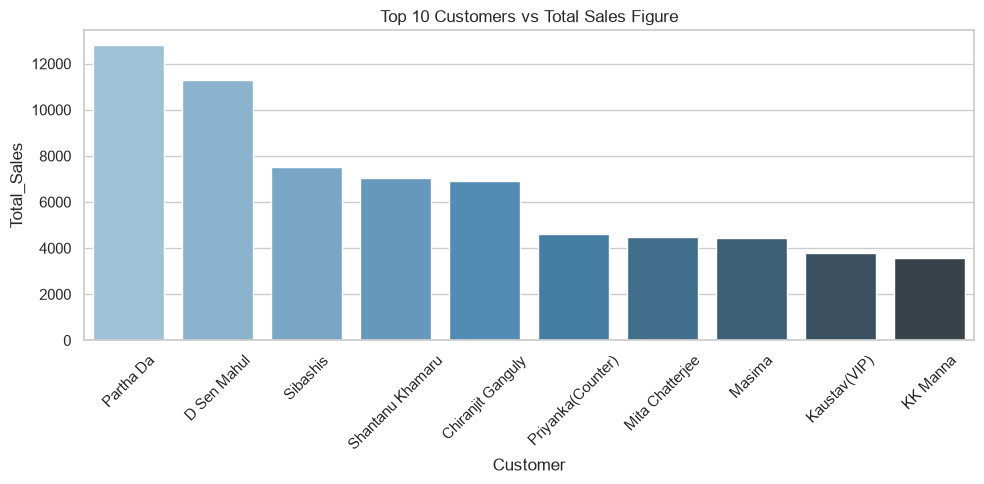

C:\Users\Hp\AppData\Local\Temp\ipykernel_26840\1145324324.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_customers_freq, x='Customer', y='Frequency', palette='Greens_d')


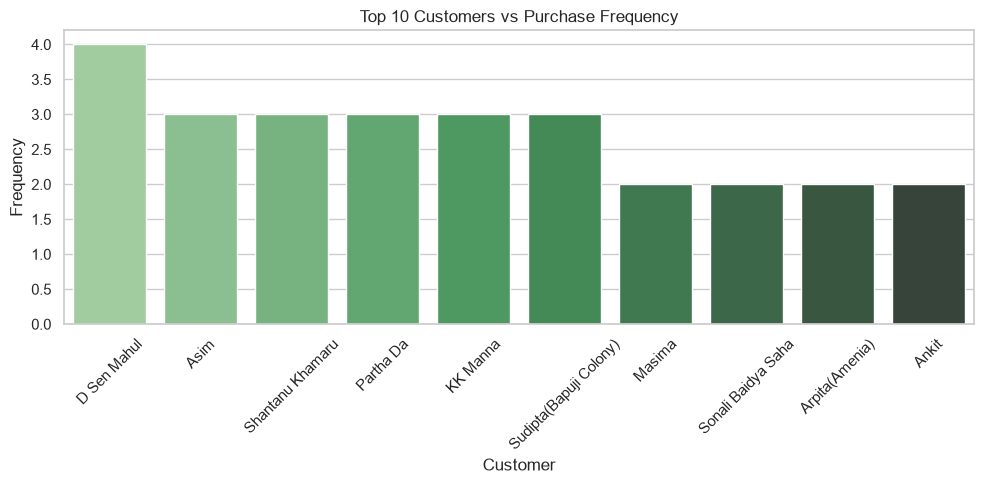

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Clean Data
excel_path = "Sales Data Turnover See You Soon 24-25.xlsx"
df_data = pd.read_excel(excel_path, sheet_name='Sheet1', skiprows=4)

clean_df = df_data.iloc[1:].copy()
clean_df.columns = ['U0', 'Invoice_No', 'U2', 'Customer', 'U4', 'Item', 'U6', 'Qty', 'U8', 'Price', 'U10', 'Total_Price', 'U12', 'U13', 'U14', 'U15']
clean_df = clean_df[['Invoice_No', 'Customer', 'Item', 'Qty', 'Price', 'Total_Price']].dropna(subset=['Item'])
clean_df['Invoice_No'] = clean_df['Invoice_No'].ffill()
clean_df['Qty'] = pd.to_numeric(clean_df['Qty'])
clean_df['Total_Price'] = pd.to_numeric(clean_df['Total_Price'])

# 2. Set Style for Charts
sns.set_theme(style="whitegrid")

# 3. Group Data by Customer
customer_summary = clean_df.groupby('Customer').agg(
    Frequency=('Invoice_No', 'nunique'),
    Total_Sales=('Total_Price', 'sum'),
    Mean_Spend=('Total_Price', 'mean'),
    Median_Spend=('Total_Price', 'median')
).reset_index()

# 4. Customer vs Total Sales Chart
top_customers_sales = customer_summary.sort_values(by='Total_Sales', ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(data=top_customers_sales, x='Customer', y='Total_Sales', palette='Blues_d')
plt.title('Top 10 Customers vs Total Sales Figure')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Customer vs Purchase Frequency Chart
top_customers_freq = customer_summary.sort_values(by='Frequency', ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(data=top_customers_freq, x='Customer', y='Frequency', palette='Greens_d')
plt.title('Top 10 Customers vs Purchase Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import numpy as np

# 1. Complete Statistical & Segmentation Analysis
customer_segment = clean_df.groupby('Customer').agg(
    Total_Frequency=('Invoice_No', 'nunique'),
    Total_Sales=('Total_Price', 'sum'),
    Mean_Spend=('Total_Price', 'mean'),
    Median_Spend=('Total_Price', 'median'),
    Average_Item_Price=('Price', 'mean')
).reset_index()

# Calculate Mode spend safely
mode_spend = clean_df.groupby('Customer')['Total_Price'].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]
).reset_index(name='Mode_Spend')

customer_segment = pd.merge(customer_segment, mode_spend, on='Customer')

# 2. Customer Segmentation based on Total Sales (VIP, Regular, Occasional)
def segment_customer(sales):
    if sales > 10000:
        return 'VIP Customer'
    elif sales > 5000:
        return 'Regular Customer'
    else:
        return 'Occasional Customer'

customer_segment['Segment'] = customer_segment['Total_Sales'].apply(segment_customer)

# Display Top 10 Segmented Customers Report
print("--- ADVANCED CUSTOMER SEGMENTATION & MIS REPORT ---")
print(customer_segment.sort_values(by='Total_Sales', ascending=False).head(10).to_string(index=False))

--- ADVANCED CUSTOMER SEGMENTATION & MIS REPORT ---
         Customer  Total_Frequency  Total_Sales  Mean_Spend  Median_Spend Average_Item_Price  Mode_Spend             Segment
        Partha Da                3        12800  193.939394         160.0          85.454545         160        VIP Customer
      D Sen Mahul                4        11290  156.805556         160.0              86.25          50        VIP Customer
         Sibashis                1         7500  750.000000         750.0              375.0         750    Regular Customer
 Shantanu Khamaru                3         7040   71.836735          60.0          65.714286          20    Regular Customer
Chiranjit Ganguly                2         6920  157.272727         140.0         141.363636         140    Regular Customer
Priyanka(Counter)                1         4600  153.333333         145.0         153.333333         140 Occasional Customer
  Mita Chatterjee                2         4490  204.090909          65.0

In [4]:
# 1. Calculate Mean, Median, and Mode of Customer Spending
customer_stats = clean_df.groupby('Customer')['Total_Price'].agg(
    Total_Spend='sum',
    Mean_Spend='mean',
    Median_Spend='median',
    Purchase_Count='count'
).reset_index()

# Calculate Mode spend per customer safely
mode_spend = clean_df.groupby('Customer')['Total_Price'].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]
).reset_index(name='Mode_Spend')

customer_stats = pd.merge(customer_stats, mode_spend, on='Customer')

print("--- CUSTOMER SEGMENTATION & STATISTICS (Top 5) ---")
print(customer_stats.head())

# 2. Find Item Which Sells the Most
item_sales = clean_df.groupby('Item')['Qty'].sum().reset_index()
top_selling_item = item_sales.sort_values(by='Qty', ascending=False).iloc[0]

print("\n--- ITEM PERFORMANCE ---")
print(f"Top Selling Item: {top_selling_item['Item']} with {top_selling_item['Qty']} total units sold!")

--- CUSTOMER SEGMENTATION & STATISTICS (Top 5) ---
               Customer  Total_Spend  Mean_Spend  Median_Spend  \
0                  Amit          280       140.0         140.0   
1  Anima Sanjoy(Bangur)         2300       115.0         115.0   
2        Anima(Trading)          560        70.0          70.0   
3                 Ankit          640        80.0          80.0   
4        Arpita(Amenia)          980        70.0          70.0   

   Purchase_Count  Mode_Spend  
0               2         140  
1              20          20  
2               8          60  
3               8          80  
4              14          70  

--- ITEM PERFORMANCE ---
Top Selling Item: Veg Thali with 606 total units sold!


In [5]:
import pandas as pd

# 1. Generate Complete MIS Summary Table
mis_summary = customer_segment[['Customer', 'Total_Frequency', 'Total_Sales', 'Mean_Spend', 'Median_Spend', 'Mode_Spend', 'Segment']]

# Sort by Total Sales to show top customers at the top
mis_summary = mis_summary.sort_values(by='Total_Sales', ascending=False)

print("==================================================")
print("         MANAGEMENT INFORMATION SYSTEM (MIS)      ")
print("==================================================")
print(f"Total Unique Customers: {len(customer_segment)}")
print(f"Total Sales Revenue: ₹{customer_segment['Total_Sales'].sum():,.2f}")
print(f"Top Selling Item: Veg Thali (606 Units Sold)")
print("--------------------------------------------------")
print("Top 5 Customers MIS Breakdown:")
print(mis_summary.head(5).to_string(index=False))
print("==================================================")

         MANAGEMENT INFORMATION SYSTEM (MIS)      
Total Unique Customers: 70
Total Sales Revenue: ₹129,000.00
Top Selling Item: Veg Thali (606 Units Sold)
--------------------------------------------------
Top 5 Customers MIS Breakdown:
         Customer  Total_Frequency  Total_Sales  Mean_Spend  Median_Spend  Mode_Spend          Segment
        Partha Da                3        12800  193.939394         160.0         160     VIP Customer
      D Sen Mahul                4        11290  156.805556         160.0          50     VIP Customer
         Sibashis                1         7500  750.000000         750.0         750 Regular Customer
 Shantanu Khamaru                3         7040   71.836735          60.0          20 Regular Customer
Chiranjit Ganguly                2         6920  157.272727         140.0         140 Regular Customer
